In [1]:
# 抑制警告和终端输出
import warnings
import sys
import os

# 设置 matplotlib 在 Jupyter notebook 中内联显示图片
%matplotlib inline

# 抑制所有警告
warnings.filterwarnings('ignore')

# 抑制特定类型的警告（可选，更精细的控制）
# warnings.filterwarnings('ignore', category=UserWarning)
# warnings.filterwarnings('ignore', category=DeprecationWarning)
# warnings.filterwarnings('ignore', category=FutureWarning)

# 抑制 tqdm 进度条输出（如果需要的话，取消下面的注释）
# from tqdm import tqdm
# from functools import partial
# tqdm = partial(tqdm, disable=True)

# 如果需要完全抑制 print 输出，可以重定向 stdout（取消注释下面的代码）
# class SuppressOutput:
#     def __init__(self):
#         self.stdout = sys.stdout
#         self.stderr = sys.stderr
#     def __enter__(self):
#         sys.stdout = open(os.devnull, 'w')
#         sys.stderr = open(os.devnull, 'w')
#     def __exit__(self, *args):
#         sys.stdout.close()
#         sys.stderr.close()
#         sys.stdout = self.stdout
#         sys.stderr = self.stderr

from Enhance_Fusion_detection import *
import model_methods

In [2]:
# model_path="/data/VLM/llava-v1.5-7b-hf"
model_path="/data/VLM/llava-1.5-13b-hf"
model_type="llava"
object="car"
DATA_ROOT="/data/dataset/MMFusion-dataset/MFNet/"
DATASET='test'
Fusion="Fusion"  # Orin 和 Fusion 和 Enhance(Orin+Fusion)
ATTENTION_TYPE="orin" # orin rel
SCENE="NIGHT" #DAY或者NIGHT或者ALL


In [3]:
model_type_to_module = {
    "qwen2.5vl": "model_methods.qwen2_5_methods",
    "qwen2vl": "model_methods.qwen2_methods",
    "llava": "model_methods.llava_methods",
    "deepseek_vl2": "model_methods.deepseekvl2_methods",
    "deepseek_vl": "model_methods.deepseekvl_methods",
    "internvl2_5": "model_methods.internvl2_5_methods"
}
# 根据model_type动态导入模块
if model_type in model_type_to_module:
    module_name = model_type_to_module[model_type]
    globals()[module_name] = __import__(module_name)
else:
    raise ValueError(f"Unsupported model type: {model_type}")
    
model,processor=load_VLM_model(model_path, model_type)
# 加载数据集
dataset_path = os.path.join(DATA_ROOT, DATASET)    
dataset_processor = SegmentationLabelProcessor(dataset_path, SCENE)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading llava model from /data/VLM/llava-1.5-13b-hf


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

In [4]:

def generate_specific_attention_map(model, processor, image, object, label, attention_type, model_type, image_type, scene):
    vi_items=[]
    ir_items=[]
    items=[]
    numofheads=int(NUM)
    model_name = (model_path).split('/')[-1]
    # 输入到其中特定的层和注意力头，返回它们融合之后的注意力图，先对它们归一化然后再相加。
    if model_type == "llava":
        if "7" in model_path:
            # 7B
            LAYERS=32
            HEADS=32
          
        elif "13" in model_path:
            # 13B
            LAYERS=40
            HEADS=40
      
        if model_name == "llava-v1.5-7b-hf":
            # items=["14_24","14_20","14_3"]
            # items=["14_24","14_13","14_26","18_10","17_11"][:numofheads] #CVPR top
            # acc TOP
            # vi_items=["11_17","14_3","14_26","18_10","14_20","10_29","17_18","14_24","17_11","17_13"][:numofheads]
            # ir_items=["14_26","11_17","14_3","10_29","14_24","17_18","17_11","14_20","18_10","11_14"][:numofheads]
            if scene == "DAY":
                vi_items=["11_17", "14_26", "14_3", "17_18", "14_24", "17_11"][:numofheads]
                ir_items=["14_26", "10_29", "11_17", "14_3", "17_18", "18_10"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["11_17", "14_3", "10_29", "14_20", "14_26", "14_24"][:numofheads]
                ir_items=["14_26", "10_29", "14_3", "11_17", "14_24", "14_20"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()

        elif model_name == "llava-1.5-13b-hf":
            # items=["13_17","13_21","15_2"]
            # vi_items=["13_17","13_21","16_2","17_19","15_2","16_20","15_26","14_20","14_21","17_2"][:numofheads]
            # ir_items=["15_2","13_17","13_21","16_20","14_21","16_2","15_26","14_20","16_25","12_20"][:numofheads]

            # vi_items=["13_17", "16_30", "13_21", "11_37", "16_31", "16_2", "15_39", "17_19", "15_2", "16_20"][:numofheads]
            # ir_items=["16_30", "15_2", "15_39", "13_17", "13_21", "11_37", "16_20", "16_31", "14_21", "16_2"][:numofheads]
            
            if scene == "DAY":
                vi_items=["13_17", "16_30", "11_37", "13_21", "15_39", "16_31"][:numofheads]
                ir_items=["16_30", "13_17", "15_39", "15_2", "11_37", "16_2"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["13_17", "16_30", "13_21", "16_31", "11_37", "14_21"][:numofheads]
                ir_items=["16_30", "13_21", "15_39", "13_17", "15_2", "11_37"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()
        if image_type=="vi":
            items=vi_items
        else:
            items=ir_items

        general_question = 'Write a general description of the image.'
        prompt = f"<image>\nUSER: {object}\nASSISTANT:"
        general_prompt = f"<image>\nUSER: {general_question} Answer the question using a single word or phrase.\nASSISTANT:"
        res_threshold=1024
        if image.size[0] > res_threshold or image.size[1] > res_threshold:
            print("image size is greater than 1024, use high_res")
            exit()
        else:
            # print("image size is less than 1024, use norm_res")
            if attention_type == "orin":
                att_results = specific_norm_res(model_methods.llava_methods.auto_param_orin_attention_llava, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)
            elif attention_type == "rel":
                att_results = specific_norm_res(model_methods.llava_methods.auto_param_rel_attention_llava, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)

        # 返回的att_results是一个字典，字典中键和值包含layer/head对应的注意力图
    # Qwen待修改
    elif model_type == "qwen2.5vl":
        if "3" in model_path:
            # 3B
            LAYERS=36
            HEADS=16
            
        elif "7" in model_path:
            # 7B
            LAYERS=28
            HEADS=28
            
        if model_name == "Qwen2.5-VL-3B-Instruct":
            # items=["24_4","27_7","23_1","25_14","21_13"，"25_8"]
            # acc TOP
            # vi_items=["27_7","25_8","27_2","20_7","27_0","25_14","20_7","23_0","20_1","29_3"][:numofheads]
            # ir_items=["27_7","27_2","27_0","20_7","20_4","22_15","20_1","23_0","22_13","25_8"][:numofheads]

            if scene == "DAY":
                vi_items=["27_7", "25_8", "27_2", "20_4", "25_14", "26_12"][:numofheads]
                ir_items=["27_2", "27_7", "27_0", "20_7", "20_4", "20_1"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["27_7", "20_4", "25_8", "27_2", "27_0", "20_1"][:numofheads]
                ir_items=["27_7", "27_2", "20_4", "20_7", "27_0", "22_15"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()
      
        elif model_name == "Qwen2.5-VL-7B-Instruct":
            # items=["19_20","19_23","21_25","19_16","18_16","19_22"]
            # acc TOP
            # vi_items=["19_20","19_16","19_22","19_23","19_21","19_17","19_25","19_19","20_16","19_15"][:numofheads]
            # ir_items=["19_21","19_23","19_20","19_16","18_16","21_26","19_25","17_27","19_22","19_17"][:numofheads]
            if scene == "DAY":
                vi_items=["19_20", "19_22", "19_23", "19_21", "19_16", "19_25"][:numofheads]
                ir_items=["19_20", "19_21", "17_27", "19_25", "21_26", "19_16"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["19_20", "19_16", "19_22", "19_17", "19_23", "19_21"][:numofheads]
                ir_items=["19_17", "19_21", "19_23", "19_20", "21_25", "19_22"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()
        if image_type=="vi":
            items=vi_items
        else:
            items=ir_items

        prompt = f"{object}"
        general_prompt = f"Write a general description of the image. Answer the question using a single word or phrase."
        if attention_type=="orin":
            att_results = specific_norm_res(model_methods.qwen2_5_methods.auto_param_orin_attention_qwen2_5, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)
        elif attention_type=="rel":
            att_results = specific_norm_res(model_methods.qwen2_5_methods.auto_param_rel_attention_qwen2_5, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)
    
    elif model_type == "qwen2vl":
        if "7" in model_path:
            LAYERS=28
            HEADS=28
        elif "2" in model_path:
            LAYERS=28
            HEADS=12

        if model_name == "Qwen2-VL-2B":
            # vi_items=["17_1", "19_8", "17_5", "19_6", "20_5", "19_9", "20_1", "17_2", "20_0", "17_4"][:numofheads]
            # ir_items=["19_6", "20_0", "14_9", "19_8", "17_2", "12_7", "14_10", "17_5", "17_1", "22_5"][:numofheads]
            if scene == "DAY":
                vi_items=["17_1", "17_4", "19_9", "17_5", "21_11", "20_1"][:numofheads]
                ir_items=["14_9", "20_0", "17_2", "19_6", "14_10", "19_8"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["17_1", "17_4", "17_2", "17_5", "21_11", "19_8"][:numofheads]
                ir_items=["20_0", "14_10", "14_9", "19_6", "20_11", "17_2"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()

        elif model_name == "Qwen2-VL-2B-Instruct":
        #    vi_items=["19_9", "17_5", "20_5", "14_7", "19_6", "17_2", "14_9", "19_10", "20_0", "17_4"][:numofheads]
        #    ir_items=["20_5", "19_9", "17_5", "14_9", "14_7", "20_10", "19_6", "17_2", "17_4", "16_1"][:numofheads]
            if scene == "DAY":
                vi_items=["14_7", "17_2", "19_9", "17_5", "20_5", "19_6"][:numofheads]
                ir_items=["20_5", "14_7", "14_9", "19_9", "17_5", "20_10"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["14_7", "20_5", "19_9", "20_1", "19_6", "17_4"][:numofheads]
                ir_items=["20_5", "19_9", "20_10", "14_7", "14_9", "17_2"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()
        elif model_name == "Qwen2-VL-7B":
            # items=["19_20","19_17","19_22","16_20","19-23","19-15"]
            # vi_items=["19_20","19_25","19_16","19_23","16_1","20_21","19_22","19_15","21_5","19_17"][:numofheads]
            # ir_items=["19_20","14_0","19_17","19_22","14_8","14_7","19_16","19_24","16_1","16_13"][:numofheads]
            if scene == "DAY":
                vi_items=["19_20", "19_25", "19_23", "19_16", "20_21", "16_1"][:numofheads]
                ir_items=["19_17", "19_20", "19_22", "19_16", "19_15", "20_19"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["19_20", "19_16", "19_25", "16_1", "20_21", "19_15"][:numofheads]
                ir_items=["19_20", "14_0", "16_9", "19_24", "19_17", "14_8"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()
        elif model_name == "Qwen2-VL-7B-Instruct":
            # items=["16_20","20_21","19_15","16_16","18-16","19-25"]
            # vi_items=["19_16","19_21","19_25","18_10","18_19","19_26","20_21","19_23","11_24","19_15"][:numofheads]
            # ir_items=["16_1","16_20","16_0","19_16","14_0","17_27","16_17","14_4","18_10","19_15"][:numofheads]
            if scene == "DAY":
                vi_items=["19_16", "19_21", "19_26", "19_15", "18_10", "19_25"][:numofheads]
                ir_items=["16_1", "19_16", "16_20", "14_0", "14_4", "17_27"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["19_16", "19_21", "11_24", "19_25", "18_10", "20_21"][:numofheads]
                ir_items=["16_1", "16_20", "17_27", "16_0", "14_0", "19_16"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()

        
        if image_type=="vi":
            items=vi_items
        else:
            items=ir_items

        prompt = f"{object}"
        general_prompt = f"Write a general description of the image. Answer the question using a single word or phrase."
        if attention_type=="orin":
            att_results = specific_norm_res(model_methods.qwen2_methods.auto_param_orin_attention_qwen2, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)
        elif attention_type=="rel":
            att_results = specific_norm_res(model_methods.qwen2_methods.auto_param_rel_attention_qwen2, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)

    elif model_type == "deepseek_vl2":
        if "tiny" in model_path:
            LAYERS=12
            HEADS=10
        elif "small" in model_path:
            LAYERS=26
            HEADS=16
            
        if model_name == "deepseek-vl2-tiny":
            # items=["8_6","7_5","10_1","7_10","9_8","10_7"]
            # vi_items=["9_6","1_1","4_2","8_4","2_6","11_6","10_6","9_2","7_8","10_2"][:numofheads]
            # ir_items=["9_6","4_2","2_6","8_4","10_6","11_6","11_3","7_7","4_7","7_8"][:numofheads]
            if scene == "DAY":
                vi_items=["9_6", "1_1", "4_2", "2_6", "10_6", "8_4"][:numofheads]
                ir_items=["9_6", "4_2", "1_1", "10_6", "2_6", "8_4"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["9_6", "8_4", "10_9", "1_1", "10_2", "7_8"][:numofheads]
                ir_items=["9_6", "4_2", "7_7", "11_3", "8_4", "0_2"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()

        elif model_name == "deepseek-vl2-small":
            # vi_items=["6-5","4-5","18-13","9-3","25-14","4-14","2-10","6-2","3-1","18-4"][:numofheads]
            # ir_items=["6-5","9-3","18-4","4-5","20-1","18-13","6-2","1-15","10-12","19-12"][:numofheads]
            if scene == "DAY":
                vi_items=["6_5", "4_5", "9_3", "6_2", "18_4", "6_12"][:numofheads]
                ir_items=["6_5", "4_5", "9_3", "6_2", "18_4", "18_4"][:numofheads]
            elif scene == "NIGHT":
                vi_items=["4_5", "6_5", "18_13", "4_6", "17_7", "6_2"][:numofheads]
                ir_items=["4_5", "6_5", "25_0", "19_12", "18_13", "6_2"][:numofheads]
            else:
                print("ERROR in scene. Please check the scene.")
                exit()

        if image_type=="vi":
            items=vi_items
        else:
            items=ir_items
            
        prompt = f"{object}"
        general_prompt = f"Write a general description of the image. Answer the question using a single word or phrase."
        if attention_type=="orin":
            att_results = specific_norm_res(model_methods.deepseekvl2_methods.auto_param_orin_attention_deepseekvl2, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)
        elif attention_type=="rel":
            att_results = specific_norm_res(model_methods.deepseekvl2_methods.auto_param_rel_attention_deepseekvl2, image, prompt, general_prompt, model, processor, label, LAYERS, HEADS, items)
    else:
        print("ERROR in generate_attention_map. Please check the type of the model.")
        exit()

    return att_results

In [5]:
def visualize(image_path,atten_map,ref_map,ref_id):
    atten_map = atten_map.astype(np.uint8)
    ref_map = ref_map.astype(np.uint8)
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)  # 转为 RGB
    def create_overlay(array, color=(255, 0, 0), alpha=0.5):
        overlay = np.zeros((*array.shape, 4), dtype=np.uint8)
        overlay[array == 1] = [*color, int(255 * alpha)]
        return overlay
    def blend_with_original(original, overlay):
        original_rgba = cv2.cvtColor(original, cv2.COLOR_RGB2RGBA)
        overlay_alpha = overlay[:, :, 3] / 255.0
        blended = original_rgba.copy()
        for c in range(3):
            blended[:, :, c] = (1 - overlay_alpha) * original_rgba[:, :, c] + overlay_alpha * overlay[:, :, c]
        return blended
    overlay1 = create_overlay(ref_map, color=(255, 0, 0), alpha=0.5)  # 红色
    overlay2 = create_overlay(atten_map, color=(0, 255, 0), alpha=0.5)  # 绿色
    blended1 = blend_with_original(original_img, overlay1)
    blended2 = blend_with_original(original_img, overlay2)

    combined = np.hstack([blended1, blended2])
    cv2.imwrite(f'./picture/{ref_id}.png', cv2.cvtColor(combined, cv2.COLOR_RGBA2BGRA))

def visualize_heatmap(image_path, attention_map, label_mask, save_path=None, colormap='jet', alpha=0.5, 
                      show_original=True, show_heatmap=True, show_overlay=True, figsize=(15, 5)):
    """
    可视化注意力热力图
    
    参数:
    ----
    image_path : str
        原始图像路径
    attention_map : np.ndarray
        注意力图（2D数组，值域通常在0-1之间）
    save_path : str, optional
        保存路径，如果为None则不保存
    colormap : str
        颜色映射方案（'jet', 'hot', 'coolwarm', 'viridis'等）
    alpha : float
        叠加透明度（0-1之间）
    show_original : bool
        是否显示原图
    show_heatmap : bool
        是否显示纯热力图
    show_overlay : bool
        是否显示叠加图
    figsize : tuple
        图像显示大小
    """
    import matplotlib
    # 在 Jupyter notebook 中使用交互式后端，移除 'Agg' 后端设置
    # matplotlib.use('Agg')  # 注释掉非交互式后端
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    from matplotlib.colors import Normalize
    
    # 配置字体以确保英文和数字正确显示
    # 使用DejaVu Sans作为默认字体，这是matplotlib的标准字体，支持英文和数字
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    
    # 在 Jupyter notebook 中启用交互模式
    plt.ion()  # 改为交互模式
    
    # 如果不是列表类型，或者是列表但长度为1，按单张图片处理
    if not isinstance(image_path, (list, tuple)) or len(image_path) == 1:
        # 读取原始图像与label_mask
        original_img = cv2.imread(image_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    else:
        # 读取两张不同模态图片并融合
        img1 = cv2.imread(image_path[0])
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2 = cv2.imread(image_path[1])
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)       
        # 平均透明度叠加（每张图片透明度为0.5）
        original_img = (img1.astype(np.float32) * 0.5 + img2.astype(np.float32) * 0.5).astype(np.uint8)

    label_mask = label_mask.astype(np.uint8)
    def create_overlay(array, color=(255, 0, 0), alpha=0.5):
        overlay = np.zeros((*array.shape, 4), dtype=np.uint8)
        overlay[array == 1] = [*color, int(255 * alpha)]
        return overlay
    def blend_with_original(original, overlay):
        original_rgba = cv2.cvtColor(original, cv2.COLOR_RGB2RGBA)
        overlay_alpha = overlay[:, :, 3] / 255.0
        blended = original_rgba.copy()
        for c in range(3):
            blended[:, :, c] = (1 - overlay_alpha) * original_rgba[:, :, c] + overlay_alpha * overlay[:, :, c]
        return blended
    # overlay1 = create_overlay(label_mask, color=(255, 0, 0), alpha=0.3)  # 红色
    label_overlay = create_overlay(label_mask, color=(0, 255, 0), alpha=0.5)  # 绿色
    label_blended = blend_with_original(original_img, label_overlay)

    
    # 确保attention_map是2D数组
    if attention_map.ndim != 2:
        raise ValueError("attention_map must be a 2D array")
    
    # 确保attention_map和图像尺寸匹配
    if attention_map.shape != original_img.shape[:2]:
        # 如果尺寸不匹配，调整attention_map大小
        attention_map = cv2.resize(attention_map, (original_img.shape[1], original_img.shape[0]), 
                                   interpolation=cv2.INTER_LINEAR)
    # if isinstance(image_path, (list, tuple)) and len(image_path) == 2:
        # attention_map = 0.9*attention_map + 0.1*label_mask
    # 归一化到0-1范围
    att_min, att_max = attention_map.min(), attention_map.max()
    if att_max > att_min:
        attention_map_norm = (attention_map - att_min) / (att_max - att_min)
    else:
        attention_map_norm = attention_map
    
    # 计算要显示的图像数量
    num_plots = sum([show_original, show_heatmap, show_overlay])
    if num_plots == 0:
        print("Warning: At least one image type must be displayed")
        return
    
    fig, axes = plt.subplots(1, num_plots, figsize=figsize)
    if num_plots == 1:
        axes = [axes]
    
    plot_idx = 0
    
    # 显示原图
    if show_original:
        #在此处切换是显示原图，还是叠加label_mask的原图
        if isinstance(image_path, (list, tuple)) and len(image_path) == 2:
            axes[plot_idx].imshow(label_blended)
        else:
            axes[plot_idx].imshow(original_img)
        
        axes[plot_idx].set_title('Original Image', fontsize=12)
        axes[plot_idx].axis('off')
        plot_idx += 1
    
    # 显示纯热力图
    if show_heatmap:
        im = axes[plot_idx].imshow(attention_map_norm, cmap=colormap, interpolation='bilinear')
        axes[plot_idx].set_title('Attention Heatmap', fontsize=12)
        axes[plot_idx].axis('off')
        plt.colorbar(im, ax=axes[plot_idx], fraction=0.046, pad=0.04)
        plot_idx += 1
    
    # 显示叠加图
    if show_overlay:
        # 获取颜色映射
        cmap = cm.get_cmap(colormap)
        heatmap_rgb = cmap(attention_map_norm)[:, :, :3]  # 获取RGB，去掉alpha通道
        heatmap_rgb = (heatmap_rgb * 255).astype(np.uint8)
        
        # 叠加到原图
        overlay = cv2.addWeighted(original_img, 1-alpha, heatmap_rgb, alpha, 0)
        axes[plot_idx].imshow(overlay)
        axes[plot_idx].set_title(f'Overlay (alpha={alpha})', fontsize=12)
        axes[plot_idx].axis('off')
        plot_idx += 1
    
    plt.tight_layout()
    
    # 保存图像
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Image saved to: {save_path}")
    
    # 在 Jupyter notebook 中，%matplotlib inline 会自动显示图形
    # 不需要显式调用 plt.show()，也不返回 fig，避免重复显示
    # plt.show()  # 已移除，避免重复显示
    
    return None  # 返回 None，避免 Jupyter 自动显示返回值



In [6]:
def CLI_get_fusion_attention_map(model, processor, ir_img, vi_img, label_mask, object, attention_type, model_type, scene):

    model_att_results={}
    model_eval_results={}
    
    # model_att_results["ir"], model_eval_results["ir"] = generate_all_head_attention_map(model, processor, ir_img, object, label, attention_type, model_type)
    # model_att_results["vi"], model_eval_results["vi"] = generate_all_head_attention_map(model, processor, vi_img, object, label, attention_type, model_type)
    
    model_att_results["vi"] = generate_specific_attention_map(model, processor, ir_img, object, label_mask, attention_type, model_type,image_type="vi", scene=scene)
    model_att_results["ir"] = generate_specific_attention_map(model, processor, vi_img, object, label_mask, attention_type, model_type, image_type="ir", scene=scene)
    if SCENE=="DAY":
        model_att_results["vi"]=model_att_results["vi"]
        model_att_results["ir"]=model_att_results["ir"]*0.8
    elif SCENE=="NIGHT":
        model_att_results["vi"]=model_att_results["vi"]*0.8
        model_att_results["ir"]=model_att_results["ir"]
    fusion_attention_map = composite_attn_map(model_att_results)

    return model_att_results, fusion_attention_map

In [7]:
# NIGHT SCENE
# Choice=9 #car_save
# Choice=3 #person_save
# Choice=22 #person_best

# DAY SCENE
# Choice=3 #car_save vi-0.6
# Choice=3,6 #person_save
# Choice=22 #person_best


Choice=40
# 按图片进行遍历检测，单张图片把所有的目标都检测出来
LIMIT = 10000
NAME = None
objects=["car","person","bike","curve","car_stop","guardrail"] #MSRS,MFNet
for items in range(len(objects)):
    if object == objects[items]:
        object_index = items+1
        break
print(f"length of dataset_processor:{len(dataset_processor)}")
NUM = len(dataset_processor) if len(dataset_processor) < LIMIT else LIMIT
SPC_count=0
for item in tqdm(range(NUM), desc="Processing images"): #2D array类型数据
    label, ir_img, vi_img, file_name = dataset_processor[item]
    # print(label, ir_img, vi_img, file_name)
    # print(file_name)
    if dataset_processor.check_class_exists(label, object_index):
        SPC_count+=1
        if SPC_count==Choice:
            label_mask = dataset_processor.extract_mask(label, object_index) # 获得对应目标的准确mask
            model_att_results, fusion_attention_map = CLI_get_fusion_attention_map(model, processor, ir_img, vi_img, label_mask, object, ATTENTION_TYPE, model_type, SCENE)
            NAME = file_name
            print(NAME)
            print("SUCCESS")
            break
            
if SPC_count==0:
    print("OBJECT IS NOT FOUND")


length of dataset_processor:188


Processing images:  54%|█████▎    | 101/188 [00:03<00:03, 27.17it/s]

01251N.png
SUCCESS


In [8]:
def visualize(image_path,atten_map,ref_map,ref_id,modal_type):
    atten_map = atten_map.astype(np.uint8)
    ref_map = ref_map.astype(np.uint8)
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)  # 转为 RGB
    def create_overlay(array, color=(255, 0, 0), alpha=0.5):
        overlay = np.zeros((*array.shape, 4), dtype=np.uint8)
        overlay[array == 1] = [*color, int(255 * alpha)]
        return overlay
    def blend_with_original(original, overlay):
        original_rgba = cv2.cvtColor(original, cv2.COLOR_RGB2RGBA)
        overlay_alpha = overlay[:, :, 3] / 255.0
        blended = original_rgba.copy()
        for c in range(3):
            blended[:, :, c] = (1 - overlay_alpha) * original_rgba[:, :, c] + overlay_alpha * overlay[:, :, c]
        return blended
    overlay1 = create_overlay(ref_map, color=(255, 0, 0), alpha=0.3)  # 红色
    overlay2 = create_overlay(atten_map, color=(0, 255, 0), alpha=0.5)  # 绿色
    blended1 = blend_with_original(original_img, overlay1)
    blended2 = blend_with_original(original_img, overlay2)

    combined = np.hstack([blended1, blended2])
    if modal_type == "vi":
        cv2.imwrite(f'./visual_result/{ref_id}_vi.png', cv2.cvtColor(combined, cv2.COLOR_RGBA2BGRA))
    elif modal_type == "ir":
        cv2.imwrite(f'./visual_result/{ref_id}_ir.png', cv2.cvtColor(combined, cv2.COLOR_RGBA2BGRA))
    else:
        cv2.imwrite(f'./visual_result/{ref_id}_fusion.png', cv2.cvtColor(combined, cv2.COLOR_RGBA2BGRA))

In [9]:
vi_att_map = min_max_scale(model_att_results["vi"])
ir_att_map = min_max_scale(model_att_results["ir"])
fusion_attention_map = min_max_scale(fusion_attention_map)

#此处要转化为热力图，二值图也可以加上
vi_img_path = os.path.join(dataset_processor.vi_path, NAME)
ir_img_path = os.path.join(dataset_processor.ir_path, NAME)

# 专门用于可视化二值图
# visualize(vi_img_path, vi_att_map, label_mask, NAME, "vi")
# visualize(ir_img_path, ir_att_map, label_mask, NAME, "ir")

Image saved to: ./visual_result/heatmap_orin_01251N.png_vi.png


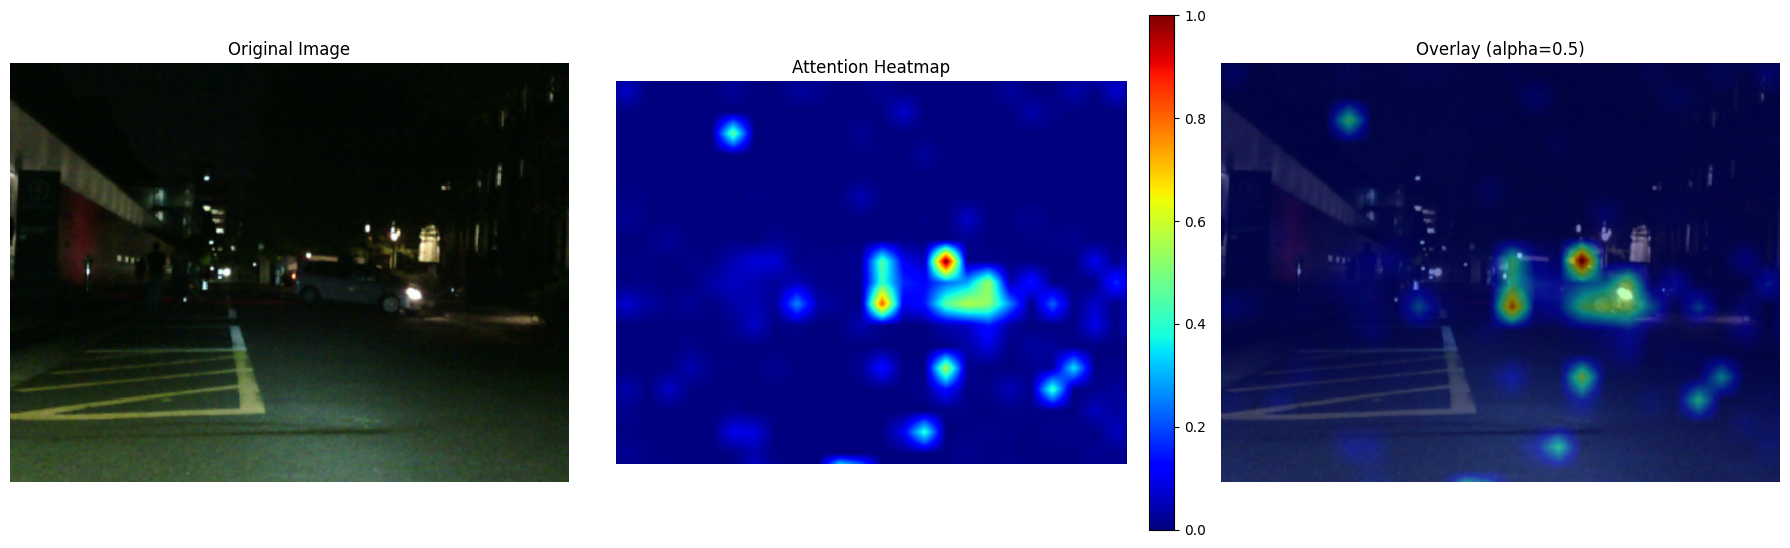

In [10]:
# 专门用于可视化热力图
visualize_heatmap(
        image_path=vi_img_path,
        attention_map=vi_att_map,  # 使用原始注意力图（0-1之间的浮点数）
        label_mask=label_mask,
        save_path=f'./visual_result/heatmap_{ATTENTION_TYPE}_{NAME}_vi.png',
        colormap='jet',  # 可选: 'jet', 'hot', 'coolwarm', 'viridis', 'plasma'等
        alpha=0.5,  # 叠加透明度
        show_original=True,
        show_heatmap=True,
        show_overlay=True,
        figsize=(18, 6)
    )

Image saved to: ./visual_result/heatmap_orin_01251N.png_ir.png


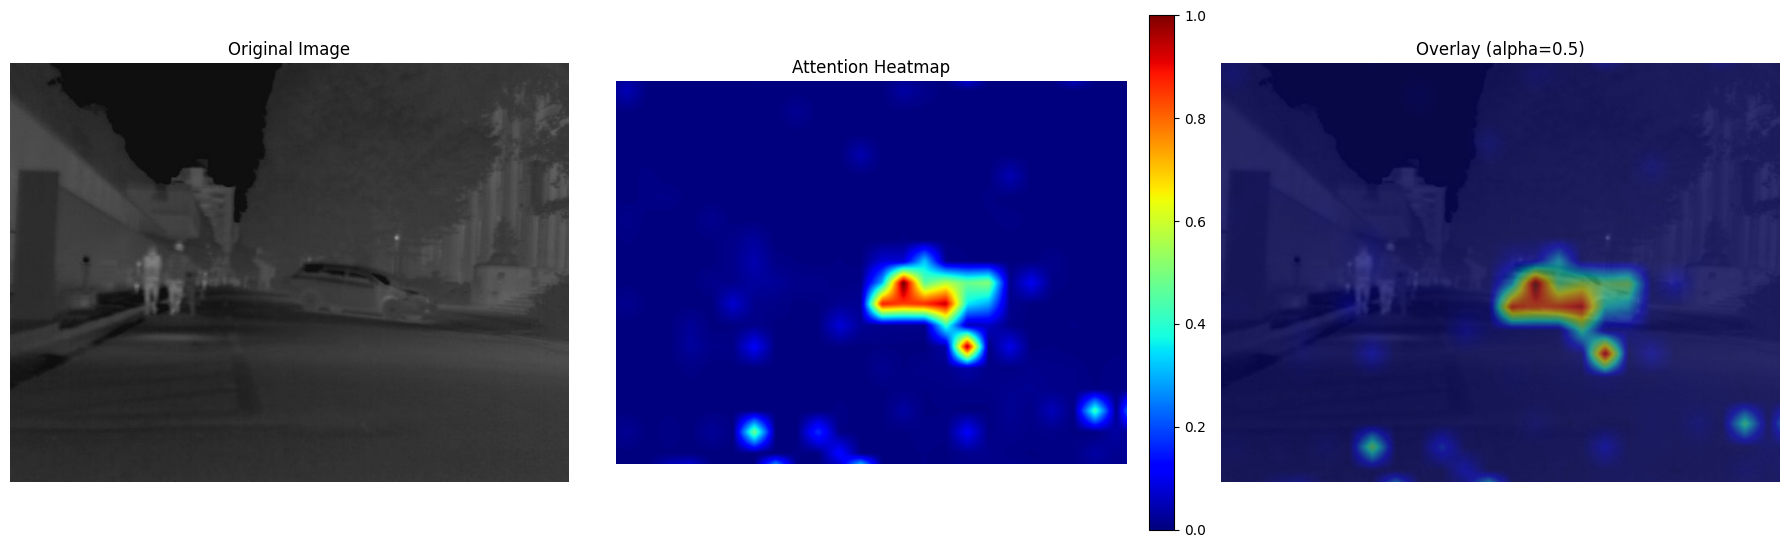

In [11]:
# 专门用于可视化热力图
visualize_heatmap(
        image_path=ir_img_path,
        attention_map=ir_att_map,  # 使用原始注意力图（0-1之间的浮点数）
        label_mask=label_mask,
        save_path=f'./visual_result/heatmap_{ATTENTION_TYPE}_{NAME}_ir.png',
        colormap='jet',  # 可选: 'jet', 'hot', 'coolwarm', 'viridis', 'plasma'等
        alpha=0.5,  # 叠加透明度
        show_original=True,
        show_heatmap=True,
        show_overlay=True,
        figsize=(18, 6)
    )

Image saved to: ./visual_result/heatmap_orin_01251N.png_fusion.png


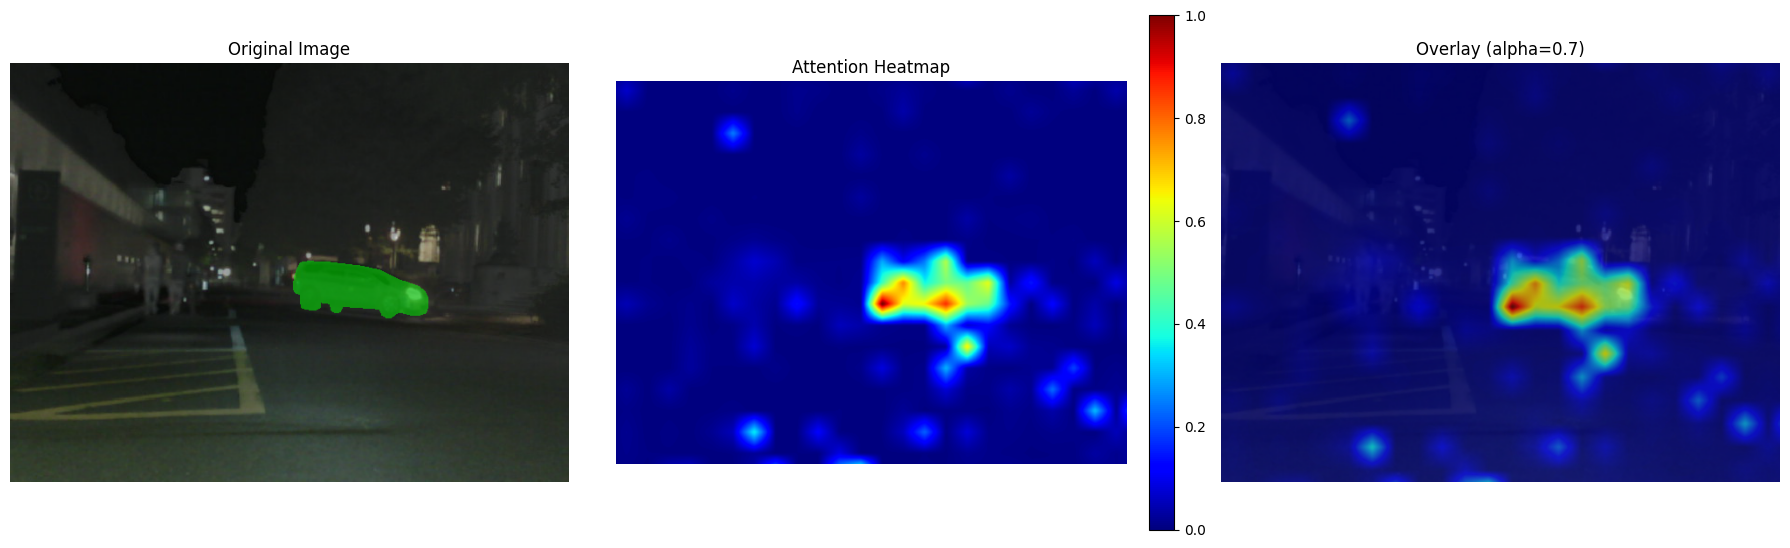

In [12]:
# 专门用于可视化热力图
visualize_heatmap(
        image_path=[vi_img_path, ir_img_path],
        attention_map=fusion_attention_map,  # 使用原始注意力图（0-1之间的浮点数）
        label_mask=label_mask,
        save_path=f'./visual_result/heatmap_{ATTENTION_TYPE}_{NAME}_fusion.png',
        colormap='jet',  # 可选: 'jet', 'hot', 'coolwarm', 'viridis', 'plasma'等
        alpha=0.7,  # 叠加透明度
        show_original=True,
        show_heatmap=True,
        show_overlay=True,
        figsize=(18, 6)
    )

In [32]:
def visualize_3d_attention_maps(vi_att_map, ir_att_map, label_mask, image_path=None, save_path=None, figsize=(12, 10)):
    """
    在同一个三维立体图中可视化注意力图
    
    参数:
    ----
    vi_att_map : np.ndarray
        VI注意力图（2D数组）
    ir_att_map : np.ndarray
        IR注意力图（2D数组）
    label_mask : np.ndarray
        标签掩码（二值图，2D数组）
    image_path : str or list, optional
        原始图像路径，可以是单个路径或路径列表（用于融合图像）
    save_path : str, optional
        保存路径，如果为None则不保存
    figsize : tuple
        图像显示大小
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import numpy as np
    import cv2
    
    # 确保所有数组都是numpy数组
    vi_att_map = np.array(vi_att_map)
    ir_att_map = np.array(ir_att_map)
    label_mask = np.array(label_mask)
    
    # 确保尺寸一致
    h, w = vi_att_map.shape
    if ir_att_map.shape != (h, w):
        ir_att_map = cv2.resize(ir_att_map, (w, h), interpolation=cv2.INTER_LINEAR)
    if label_mask.shape != (h, w):
        label_mask = cv2.resize(label_mask.astype(np.float32), (w, h), interpolation=cv2.INTER_NEAREST).astype(np.uint8)
    
    # 读取并处理原始图像（与visualize_heatmap中的逻辑一致）
    original_img = None
    if image_path is not None:
        if not isinstance(image_path, (list, tuple)) or len(image_path) == 1:
            # 读取原始图像与label_mask
            img_path = image_path if isinstance(image_path, str) else image_path[0]
            original_img = cv2.imread(img_path)
            if original_img is not None:
                original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
                # 调整图像尺寸以匹配attention map
                if original_img.shape[:2] != (h, w):
                    original_img = cv2.resize(original_img, (w, h), interpolation=cv2.INTER_LINEAR)
        else:
            # 读取两张不同模态图片并融合
            img1 = cv2.imread(image_path[0])
            img2 = cv2.imread(image_path[1])
            if img1 is not None and img2 is not None:
                img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
                img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
                # 调整尺寸
                if img1.shape[:2] != (h, w):
                    img1 = cv2.resize(img1, (w, h), interpolation=cv2.INTER_LINEAR)
                if img2.shape[:2] != (h, w):
                    img2 = cv2.resize(img2, (w, h), interpolation=cv2.INTER_LINEAR)
                # 平均透明度叠加（每张图片透明度为0.5）
                original_img = (img1.astype(np.float32) * 0.5 + img2.astype(np.float32) * 0.5).astype(np.uint8)
        
        # 如果image_path是列表且长度为2，叠加label_mask（与visualize_heatmap一致）
        if isinstance(image_path, (list, tuple)) and len(image_path) == 2 and original_img is not None:
            label_mask_uint8 = label_mask.astype(np.uint8)
            def create_overlay(array, color=(255, 0, 0), alpha=0.5):
                overlay = np.zeros((*array.shape, 4), dtype=np.uint8)
                overlay[array == 1] = [*color, int(255 * alpha)]
                return overlay
            def blend_with_original(original, overlay):
                original_rgba = cv2.cvtColor(original, cv2.COLOR_RGB2RGBA)
                overlay_alpha = overlay[:, :, 3] / 255.0
                blended = original_rgba.copy()
                for c in range(3):
                    blended[:, :, c] = (1 - overlay_alpha) * original_rgba[:, :, c] + overlay_alpha * overlay[:, :, c]
                return blended
            label_overlay = create_overlay(label_mask_uint8, color=(0, 255, 0), alpha=0.5)  # 绿色
            original_img = blend_with_original(original_img, label_overlay)
            # 转换回RGB（去掉alpha通道）
            original_img = original_img[:, :, :3]
    
    # 创建坐标网格
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    
    # 创建单个3D图形
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # 在底部（z=0）显示原始图像
    if original_img is not None:
        # 将图像归一化到0-1范围
        img_normalized = original_img.astype(np.float32) / 255.0
        # 创建z=0的平面
        Z_bottom = np.zeros_like(X)
        # 使用plot_surface显示图像，将图像颜色映射到表面
        # facecolors需要形状为(n-1, m-1, 3)的数组，其中n和m是网格的行数和列数
        # 由于X和Y是(h, w)，facecolors应该是(h-1, w-1, 3)
        # 对图像进行裁剪以匹配facecolors的要求
        if img_normalized.shape[2] == 3:
            img_for_surface = img_normalized[:-1, :-1, :]
        else:
            img_for_surface = img_normalized[:-1, :-1, :3]
        ax.plot_surface(X, Y, Z_bottom, facecolors=img_for_surface, 
                       rstride=1, cstride=1, shade=False, alpha=0.9)
    
    # 计算z轴范围
    vi_max = vi_att_map.max()
    ir_max = ir_att_map.max()
    z_max = max(vi_max, ir_max)
    
    # 绘制vi_att_map (蓝色山峰图) - 数值低于0.08的部分完全透明
    # 创建透明度掩码（形状为(h, w)）
    vi_alpha = np.where(vi_att_map >= 0.1, 0.6, 0.0)  # 高于等于0.08的alpha=0.4，低于0.08的alpha=0
    # 获取colormap并应用
    cmap_vi = plt.cm.get_cmap('Blues')
    vi_normalized = (vi_att_map - vi_att_map.min()) / (vi_att_map.max() - vi_att_map.min() + 1e-8)
    vi_colors = cmap_vi(vi_normalized)[:-1, :-1, :3]  # 去掉最后一行和列，匹配facecolors形状(h-1, w-1, 3)
    # 创建RGBA颜色数组
    vi_facecolors = np.zeros((vi_colors.shape[0], vi_colors.shape[1], 4))
    vi_facecolors[:, :, :3] = vi_colors
    vi_facecolors[:, :, 3] = vi_alpha[:-1, :-1]  # 应用透明度掩码，形状匹配为(h-1, w-1)
    surf_vi = ax.plot_surface(X, Y, vi_att_map, facecolors=vi_facecolors, 
                              linewidth=0, antialiased=True, shade=True,
                              label='VI Attention')
    
    # 绘制ir_att_map (橙红色山峰图) - 数值低于0.08的部分完全透明
    # 创建透明度掩码（形状为(h, w)）
    ir_alpha = np.where(ir_att_map >= 0.1, 0.6, 0.0)  # 高于等于0.08的alpha=0.4，低于0.08的alpha=0
    # 获取colormap并应用
    cmap_ir = plt.cm.get_cmap('Oranges')
    ir_normalized = (ir_att_map - ir_att_map.min()) / (ir_att_map.max() - ir_att_map.min() + 1e-8)
    ir_colors = cmap_ir(ir_normalized)[:-1, :-1, :3]  # 去掉最后一行和列，匹配facecolors形状(h-1, w-1, 3)
    # 创建RGBA颜色数组
    ir_facecolors = np.zeros((ir_colors.shape[0], ir_colors.shape[1], 4))
    ir_facecolors[:, :, :3] = ir_colors
    ir_facecolors[:, :, 3] = ir_alpha[:-1, :-1]  # 应用透明度掩码，形状匹配为(h-1, w-1)
    surf_ir = ax.plot_surface(X, Y, ir_att_map, facecolors=ir_facecolors, 
                              linewidth=0, antialiased=True, shade=True,
                              label='IR Attention')
    
    # 设置标题和坐标轴标签
    ax.set_title('3D Attention Maps Visualization', fontsize=16, pad=20)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_zlabel('Attention Value', fontsize=12)
    
    # 设置视角（沿z轴逆时针旋转15度：45 + 15 = 60）
    ax.view_init(elev=30, azim=30)
    
    # 添加颜色条（使用vi_att_map的范围作为主颜色条）
    cbar_vi = plt.colorbar(surf_vi, ax=ax, shrink=0.5, pad=0.1, label='VI Attention (Blue)')
    
    # 添加图例（通过创建代理对象）
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', alpha=0.4, label='VI Attention Map'),
        Patch(facecolor='orange', alpha=0.8, label='IR Attention Map')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    
    # 保存图像
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"3D visualization saved to: {save_path}")
    
    return fig


3D visualization saved to: ./visual_result/3d_visualization_orin_01251N.png.png


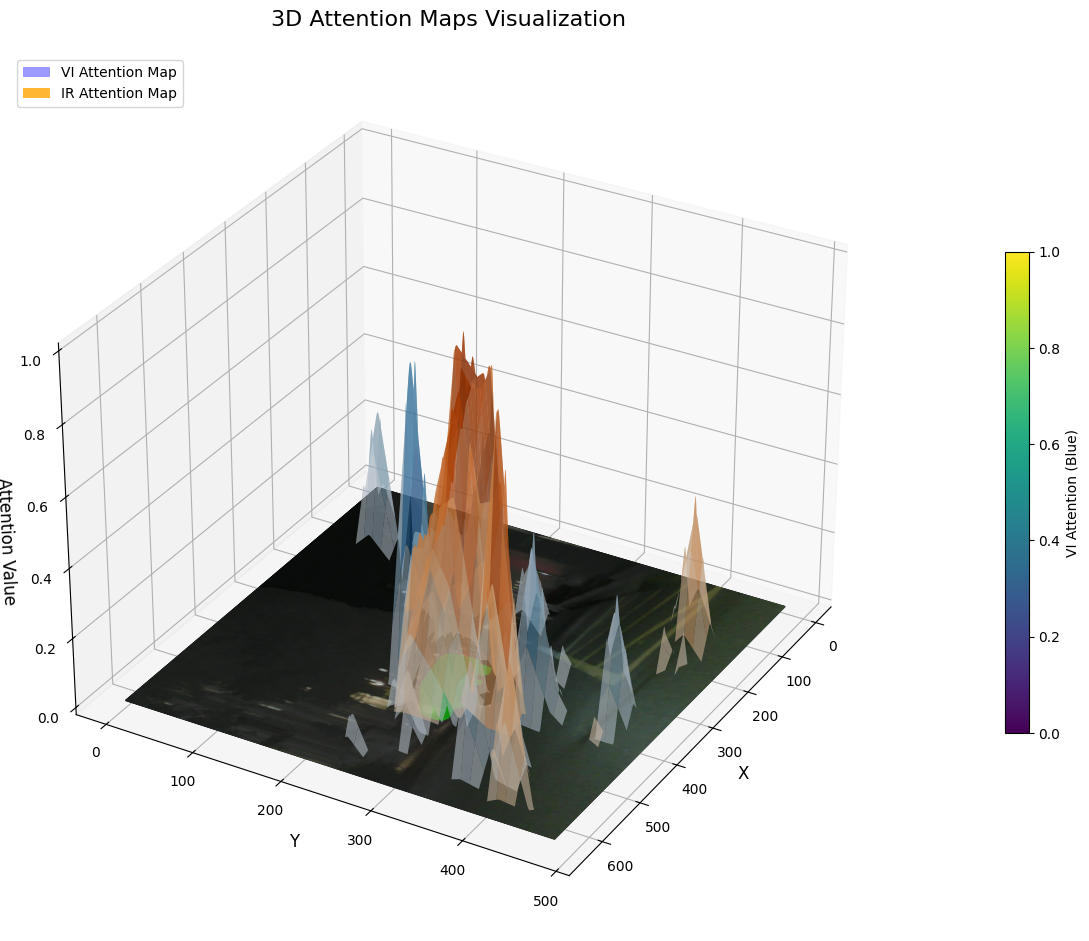

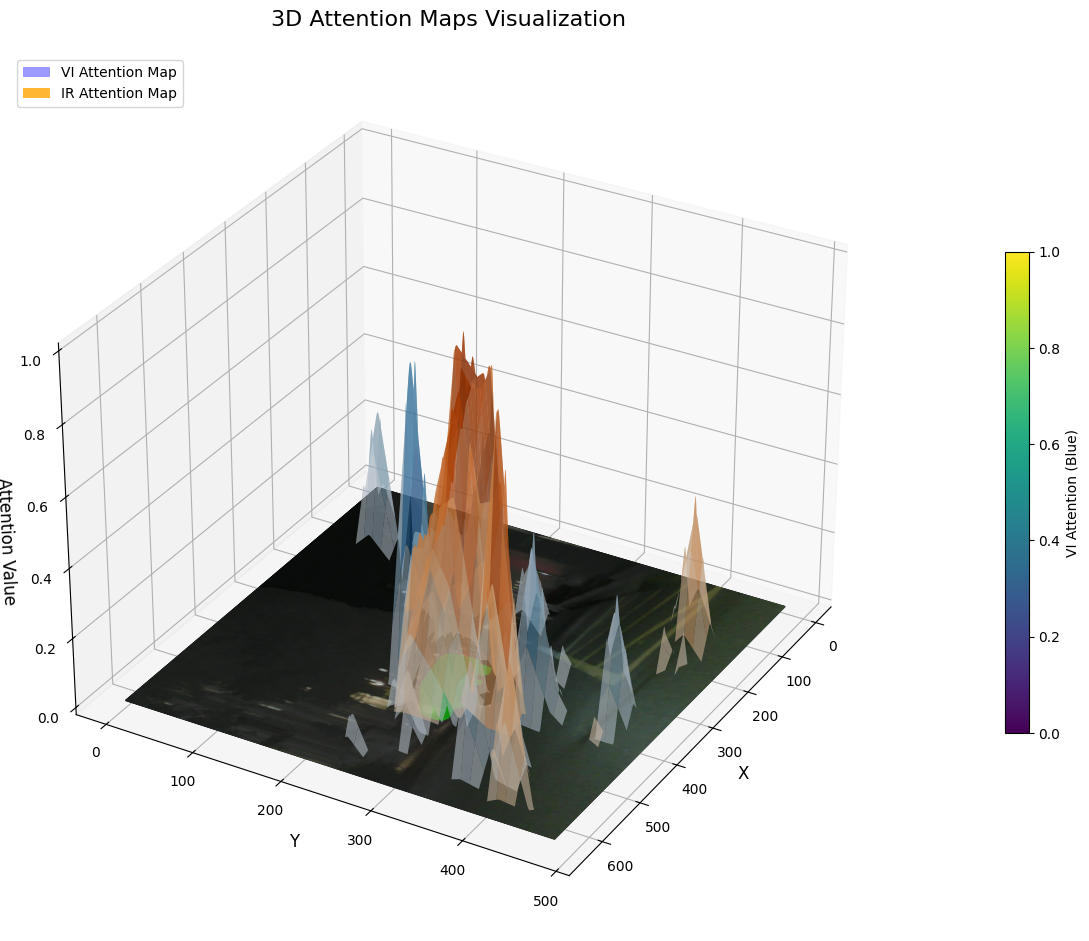

In [33]:
# 三维立体图可视化
visualize_3d_attention_maps(
    vi_att_map=vi_att_map,
    ir_att_map=ir_att_map,
    label_mask=label_mask,
    image_path=[vi_img_path, ir_img_path],  # 传入图像路径，与visualize_heatmap的fusion方式一致
    save_path=f'./visual_result/3d_visualization_{ATTENTION_TYPE}_{NAME}.png',
    figsize=(12, 10)
)
